Task 2: Unemployment Analysis with Python

C:\Users\HP\AppData\Local\Temp\ipykernel_10420\2234558175.py:8: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


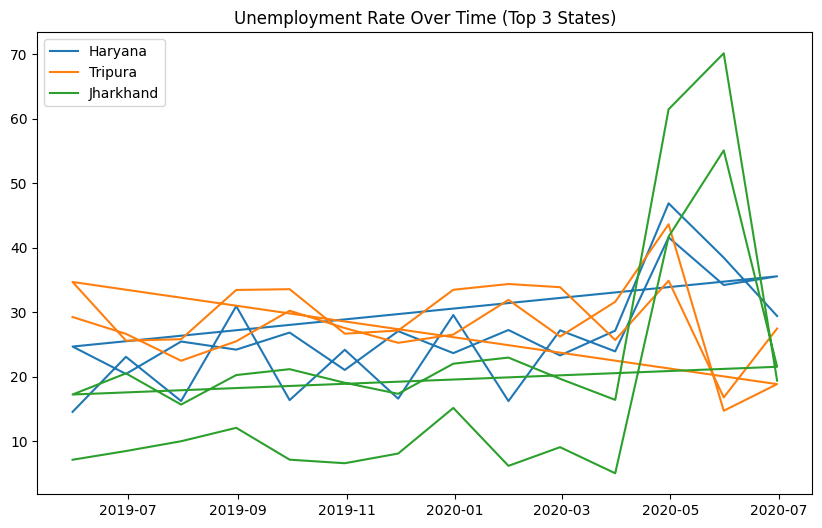

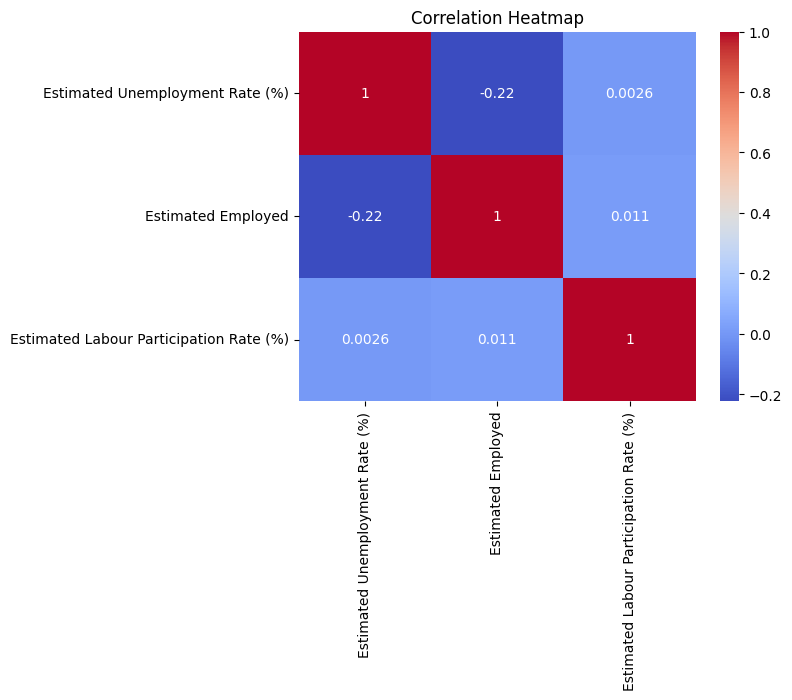

Pre-COVID Mean: 9.61486394557823
Post-COVID Mean: 20.194342105263157


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Unemployment in India.csv')
df = df.dropna()
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

# EDA: Average unemployment rate by region
region_stats = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

# Time Series Line Chart
top_3_states = ['Haryana', 'Tripura', 'Jharkhand']
plt.figure(figsize=(10, 6))
for state in top_3_states:
    state_data = df[df['Region'] == state]
    plt.plot(state_data['Date'], state_data['Estimated Unemployment Rate (%)'], label=state)
plt.title('Unemployment Rate Over Time (Top 3 States)')
plt.legend()
plt.show()

# Heatmap
numeric_df = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# COVID Comparison (Add as a Markdown cell in Jupyter)
pre_covid = df[df['Date'] < '2020-04-01']
post_covid = df[df['Date'] >= '2020-04-01']
print("Pre-COVID Mean:", pre_covid['Estimated Unemployment Rate (%)'].mean())
print("Post-COVID Mean:", post_covid['Estimated Unemployment Rate (%)'].mean())

# Observations: The data shows a massive spike in unemployment post-April 2020 due to pandemic lockdowns.